# Value + momentum everywhere — the famous "free lunch" combo, retested 🌍
### Two legendary strategies that supposedly work in *every* market and hedge each other — do they still, on data anyone can download?

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Just_diversification_arithmetic%3F: Confirmed](https://img.shields.io/badge/Just_diversification_arithmetic%3F-Confirmed-8b949e?style=flat-square)

In 2013 three of the most respected people in quantitative finance — Cliff Asness, Tobias Moskowitz and Lasse Pedersen — published *"Value and Momentum Everywhere"*: buy what's **cheap** (value) and what's **rising** (momentum), in stocks, countries, currencies, bonds *and* commodities, and because the two strategies zig when the other zags, the **50/50 blend** is the closest thing finance has to a free lunch. Their numbers were stunning — blended Sharpe ratios near 1, everywhere, for forty years.

We rebuild the whole thing on **free data** — 13 country stock-market ETFs, 9 major currencies, 3 US Treasury futures and 8 commodity futures — and ask the only question that matters: **does the free lunch show up on the part of the tape you could actually have traded?**

> 📓 **Plain-language layer.** Want the HAC *t*-stats, the placebo and the diversification arithmetic? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Data notes up front.** Our ETF panel is a *survivor* list (all still trade in 2026); FX is spot only (no carry); futures are continuous front-month series with known roll noise. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from value_momentum_everywhere import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    PANELS = data.load_sleeves()
    SLEEVES = {k: st.sleeve_series(v) for k, v in PANELS.items()}
else:
    PANELS = SLEEVES = None
print("real sleeve cache present:", HAVE_REAL)

# frozen headline numbers (mirror of docs/results.md)
R = {'as_of': '2026-05-31', 'fingerprint': '2cd41e1339cb', 'sleeves': [('EQ', 13, -0.25, -1.35, -0.01, -0.06, -0.16, -0.73, -0.16, 349, '1997-05'), ('FX', 9, 0.1, 0.46, -0.01, -0.07, 0.04, 0.2, -0.03, 270, '2002-09'), ('BOND', 3, -0.22, -1.19, -0.19, -0.97, -0.36, -1.63, -0.11, 203, '2001-11'), ('CMD', 8, 0.14, 0.67, -0.32, -1.72, -0.15, -0.86, 0.17, 296, '2001-10')], 'mean_rho': -0.03, 'glob': {'val': (0.01, 0.03, 0.4, 248), 'mom': (-0.38, -1.95, -28.0, 296), 'combo': (-0.29, -1.49, -15.7, 296)}, 'sub_pre': (-0.5, -1.64, 123), 'sub_post': (-0.13, -0.54, 174), 'rho_global': 0.145, 'pred_sr': -0.267, 'real_sr': -0.267, 'sr_val': 0.01, 'sr_mom': -0.41, 'placebo': {'mean_sharpe': 0.01, 'sd': 0.19, 'mean_t': 0.07, 'frac': 4, 'n_seeds': 50}, 'turnover': 0.65, 'costs': [(5.0, -1.88, -2.42, -0.37, -1.91), (10.0, -1.88, -2.81, -0.43, -2.21), (20.0, -1.88, -3.59, -0.55, -2.83)], 'robust': [('halves not thirds', -0.48, -2.4), ('mom 12-0 (no skip)', -0.34, -1.76), ('value incl. last year', -0.19, -0.88)], 'syn': [('null (no edges)', -0.04, -0.07, -0.08, -0.52, 0.03, -0.13, -0.13), ('planted VAL+MOM', 2.27, 1.49, 2.32, 14.12, 0.18, 2.51, 2.51)]}


real sleeve cache present: True


## The answer first

| Question | Answer |
|---|---|
| Does value pay everywhere? | **Not here.** Across the four sleeves its Sharpe sits between -0.25 and 0.14 — statistical zero in every one. |
| Does momentum pay everywhere? | **Not here.** Same story — the *best* sleeve is roughly flat, the worst (commodities) is outright negative. |
| Do they hedge each other? | **Barely.** The famous strong negative correlation (~−0.5 in the paper) shows up as a feeble **-0.03** average on our tape. |
| So does the 50/50 combo rescue it? | **No.** The everywhere-combo comes out at Sharpe **-0.29** (*t* = -1.49) — the *wrong sign*. Blending can only average what the ingredients bring, and here they brought nothing. |

> The paper's arithmetic is impeccable — diversification genuinely works. What's missing on our post-1997 free tape is the **raw material**: neither premium shows up to be blended.

## 1 · The claim

> *"Cheap assets beat expensive ones. Rising assets keep rising. This is true in stocks, country indices, currencies, bonds and commodities — and because value and momentum are negatively correlated, holding both is dramatically better than holding either."*

That's Asness–Moskowitz–Pedersen (2013), *Journal of Finance* — 1972–2011 data, blended Sharpes near 1. It launched a thousand multi-factor funds. We test it the way a retail reader could: **value** = what fell over the past 5 years (skipping the last year), **momentum** = what rose over the past 12 months (skipping the last month), long the top third, short the bottom third, in each of four asset classes, rebalanced monthly.

## 2 · So what?

This is arguably **the** foundational claim of factor investing — if value and momentum pay everywhere and hedge each other, every portfolio should hold both, always. Hundreds of billions of dollars are allocated on that premise. But almost all of the evidence comes from *one* sample ending in 2011, and the desk has already caught the pieces decaying one by one: FX momentum ([147](../../147-fx-momentum/)) — gone; long-term reversal on stocks ([196](../../196-long-term-reversal/)) — beta in disguise. The combo is the last line of defence: even weak ingredients, blended, might still clear the bar. That's what we test.

## 3 · How would we even know?

Four sleeves, one identical recipe:

1. **Country stocks** — 13 country ETFs (US, Japan, Germany, UK, France, Italy, Spain, Australia, Canada, Hong Kong, Singapore, Sweden, Switzerland), total-return, since 1996.
2. **Currencies** — 9 majors vs the dollar (spot).
3. **Bonds** — 5-, 10- and 30-year US Treasury futures.
4. **Commodities** — oil, gas, gold, silver, copper, corn, soybeans, wheat futures.

Each month, in each sleeve: rank by the signal, go long the top third, short the bottom third, hold next month (that's the one-month execution lag — no peeking). Average the four sleeves into a **global value**, **global momentum** and **global 50/50 combo** portfolio. Then let a robust *t*-test judge.

## 4 · The teardown — let's actually look

**First, the ingredients.** Value and momentum Sharpe ratios, sleeve by sleeve. The paper says every bar should be comfortably positive.

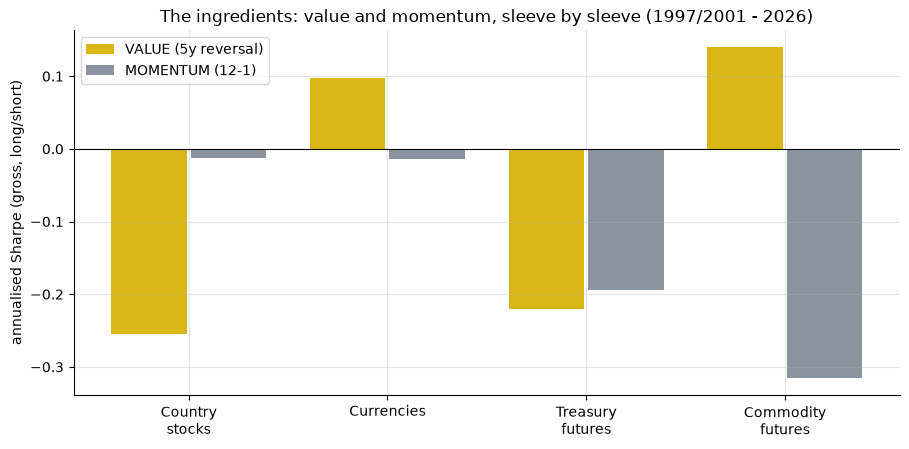

VAL Sharpes: [-0.25, 0.1, -0.22, 0.14]
MOM Sharpes: [-0.01, -0.01, -0.19, -0.32]


In [2]:
names = [s[0] for s in R['sleeves']]
if HAVE_REAL:
    stats = {k: st.sleeve_stats(SLEEVES[k]) for k in names}
    vals = [stats[k]['val']['sharpe'] for k in names]
    moms = [stats[k]['mom']['sharpe'] for k in names]
else:
    vals = [s[2] for s in R['sleeves']]; moms = [s[4] for s in R['sleeves']]
x = np.arange(len(names))
fig, ax = plt.subplots(figsize=(9.2, 4.6))
ax.bar(x-0.2, vals, 0.38, color=AMBER, label='VALUE (5y reversal)')
ax.bar(x+0.2, moms, 0.38, color=GREY, label='MOMENTUM (12-1)')
ax.axhline(0, c='k', lw=.8)
ax.set_xticks(x); ax.set_xticklabels(['Country\nstocks','Currencies','Treasury\nfutures','Commodity\nfutures'])
ax.set_ylabel('annualised Sharpe (gross, long/short)')
ax.set_title('The ingredients: value and momentum, sleeve by sleeve (1997/2001 - 2026)')
ax.legend(); plt.tight_layout(); plt.show()
print('VAL Sharpes:', [round(v,2) for v in vals]); print('MOM Sharpes:', [round(m,2) for m in moms])

Not one bar looks like the paper. Value tops out at Sharpe **+0.14** (commodities) and bottoms at **-0.25** (country stocks); momentum's best is flat and its worst — commodities — is **-0.32**. None of the eight legs is statistically distinguishable from zero.

**Now the famous combo.** Average the four sleeves into global portfolios and cumulate a dollar.

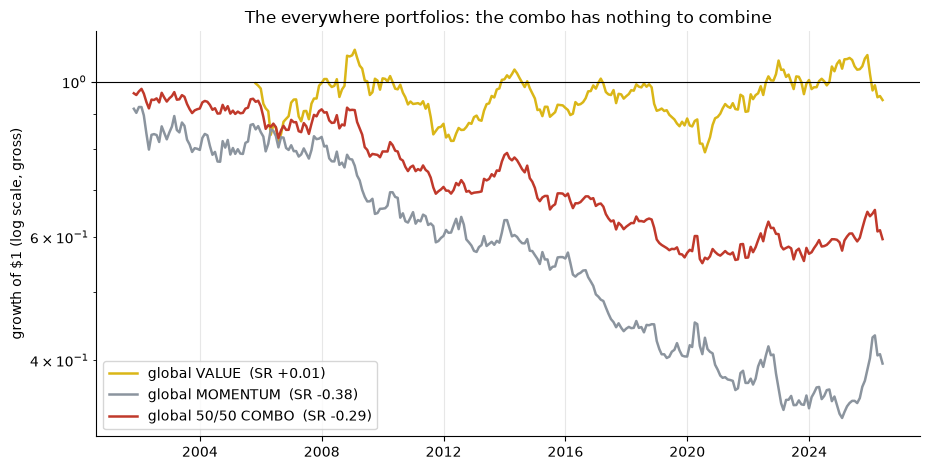

global combo: SR -0.29  HAC t -1.49


In [3]:
if HAVE_REAL:
    gv = st.global_series(SLEEVES, 'val'); gm = st.global_series(SLEEVES, 'mom')
    gc = st.global_series(SLEEVES, 'combo')
    fig, ax = plt.subplots(figsize=(9.4, 4.8))
    for s, cname, lab in ((gv, AMBER, 'global VALUE'), (gm, GREY, 'global MOMENTUM'),
                          (gc, RED, 'global 50/50 COMBO')):
        ax.plot((1+s).cumprod(), color=cname, lw=1.8, label=f'{lab}  (SR {st.sharpe(s):+.2f})')
    ax.axhline(1, c='k', lw=.8)
    ax.set_yscale('log'); ax.set_ylabel('growth of $1 (log scale, gross)')
    ax.set_title('The everywhere portfolios: the combo has nothing to combine')
    ax.legend(); plt.tight_layout(); plt.show()
else:
    print('cache miss - frozen numbers:', R['glob'])
print('global combo: SR %.2f  HAC t %.2f' % (R['glob']['combo'][0], R['glob']['combo'][1]))

A dollar in the global 50/50 combo *shrinks* — Sharpe **-0.29**, robust *t* = **-1.49**, over 296 months. And that's **gross**: no trading costs, no borrow on the short legs. Costs only push it further down.

**But wait — wasn't the magic the *hedge*?** The paper's deepest claim is that value and momentum are strongly negatively correlated (~−0.5), so the blend is much better than the parts. Here's that correlation, sleeve by sleeve.

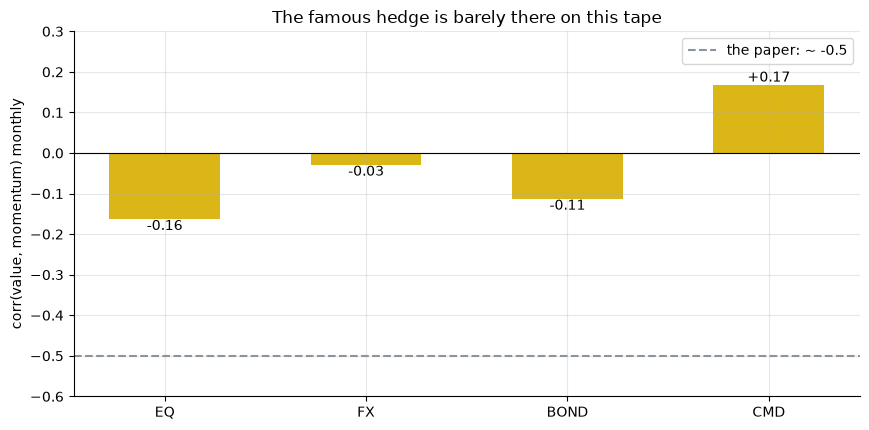

per-sleeve rho: [-0.16, -0.03, -0.11, 0.17]


In [4]:
if HAVE_REAL:
    rhos = [st.sleeve_stats(SLEEVES[k])['rho'] for k in names]
else:
    rhos = [s[8] for s in R['sleeves']]
fig, ax = plt.subplots(figsize=(8.8, 4.4))
ax.bar(names, rhos, color=[GREEN if r < -0.3 else AMBER for r in rhos], width=.55)
ax.axhline(-0.5, ls='--', c=GREY, label='the paper: ~ -0.5')
ax.axhline(0, c='k', lw=.8)
for i, r in enumerate(rhos): ax.annotate(f'{r:+.2f}', (i, r), ha='center',
                                         va='top' if r < 0 else 'bottom')
ax.set_ylabel('corr(value, momentum) monthly'); ax.set_ylim(-0.6, 0.3)
ax.set_title('The famous hedge is barely there on this tape')
ax.legend(); plt.tight_layout(); plt.show()
print('per-sleeve rho:', [round(r,2) for r in rhos])

Average correlation **-0.03** — a whisper of the paper's −0.5. With ~zero correlation, blending two strategies still helps (risk averages out) — but the *return* of the blend is just the average of the two returns. Average of zero and zero is zero.

> 🔬 **For the quants:** the combo's Sharpe matches the two-asset diversification formula to the third decimal — see the quants notebook. There is no residual "everywhere magic" beyond arithmetic.

## 5 · The verdict

- **Signal — Weak.** Forty years of literature (and a genuinely great paper) say the premia are real; **our** free-data tape (1997/2001→2026) can't certify any of it — all eight sleeve-legs are statistical zero and the global combo lands at Sharpe **-0.29** (*t* = -1.49), the wrong sign.
- **Tradability — Mirage.** The combo is negative **before** costs; after 10 bps one-way and short-leg borrow it's worse. There is nothing to harvest here.
- **"Just diversification arithmetic?" — Confirmed.** The combo's Sharpe equals the textbook two-asset formula exactly — diversification works, but it can only blend what the ingredients deliver. (In [study 401](../../401-signal-stacking/) the same arithmetic multiplied *noise*; here it multiplies two once-real premia that this tape no longer pays.)

## 6 · Going further 🚪

- **Our tape is not their tape.** AMP had 1972–2011, dozens of markets per class, futures with proper roll handling, and value measures like book-to-market. We have 13 survivor ETFs, 9 spot pairs, 11 noisy continuous futures, 1997/2001–2026. Absence of evidence on a thin free tape is not proof the premia never existed — it *is* proof you couldn't have harvested them here.
- **The dates rhyme with McLean–Pontiff.** Most of our sample is *post-publication* — exactly where documented premia historically fade. Our pre/post-2012 split shows nothing clears the bar in either half.
- **The honest lesson survives.** Negative-to-zero correlation between strategies is real and valuable — *when the strategies themselves pay*. Hunt the ingredients, not the blender.

*Think the free lunch is still being served somewhere? Bring a sleeve where value or momentum clears a HAC t of 2 on post-2012 free data — then we'll blend.*